# Compare Inversion Calls Across Treatments
What would be interesting to see is the inversion-calling performance in linked reads across inversion sizes and depths. Since we already created the assessment tables from the individual size-class data exploration, we can read those in without having to reprocess those data.

In [10]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(ggh4x)
options(warn = -1)

Read in the LEVIATHAN linked-read variant assessments. Remove the `inversion` and `id` columns. We will add the leviathan candidates as their own `technology` and do the same with the pooled data.

In [11]:
.lev <- read.csv("assess_sv_leviathan/visor/linkedread.sv.assessment", header = T) %>%
    select(-inversion, -id, -candidate)
.lev$technology[.lev$sample == 11] <- "linkedread (pooled)"
.lev$zygosity[.lev$sample == 11] <- "homozygous"

# rm pooled from the candidates
.lev_cand <- select(.lev, -assessment) %>% rename("assessment" = assess_cand) %>% filter(sample < 11)

# rename the false negative (filtered) to "true positive" to posit an ideal world where candidates were detected
.lev_cand$assessment[grepl("filtered", .lev_cand$assessment)] <- "true positive"
.lev_cand$assessment[grepl("undetected", .lev_cand$assessment)] <- "false negative"
.lev_cand$technology <- "linkedread (candidates)"

leviathan <- rbind(select(.lev, -assess_cand), .lev_cand)

table(leviathan$technology)
table(leviathan$assessment)
head(leviathan)


             linkedread linkedread (candidates)     linkedread (pooled) 
                   2400                    2400                     240 


false negative  true negative  true positive 
          1236           1300           2504 

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan


In [12]:
naibr <- read.csv("assess_sv_naibr/visor/linkedread.sv.assessment", header = T) %>%
    select(-inversion, -id)
table(naibr$assessment)
head(naibr)


false negative  true negative  true positive 
          1323            650            667 

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr


For the short reads, we can rename the values in the `technology` column as `shortread`

In [13]:
delly <- read.csv("assess_sv_delly/linkedread.sv.assessment", header = T)
delly$technology <- "shortread"
delly <- select(delly, -inversion, -id)
table(delly$assessment)
head(delly)


false negative  true negative  true positive 
           407            650           1343 

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,shortread,delly2


Read in the long-read variant assessment. Rename the columns because I clearly wasn't consistent doing this over and over again.

In [14]:
longread <- read.csv("longread_workflow/longread.sv.assessment", header = T)
longread <- rename(longread, "simulated" = present, "technology" = platform)
longread$method <- "sniffles"
longread$sample <- as.integer(gsub("sample_", "", longread$sample))
table(longread$assessment)
head(longread)


false negative  true negative  true positive 
          1194           1950           4056 

,sample,contig,position_start,position_end,size,simulated,zygosity,assessment,depth,technology,method
,<int>,<chr>,<int>,<int>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,1,2L,11529165,15060030,large,TRUE,homozygous,false negative,0.5,pacbio,sniffles
2,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,0.5,ontlong,sniffles
3,1,2L,11529165,15060030,large,TRUE,homozygous,false negative,0.5,ontshort,sniffles
4,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,2.0,pacbio,sniffles
5,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,2.0,ontlong,sniffles
6,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,2.0,ontshort,sniffles


In [15]:
assess <- rbind(leviathan, naibr, delly, longread)
head(assess)

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan


Let's also make some of the columns factors.

In [16]:
assess$depth <- as.factor(assess$depth)
assess$size <- factor(assess$size, ordered = T, levels = c("small","medium","large","xl"))
assess$technology <- factor(assess$technology, ordered = T, levels = c("linkedread", "linkedread (pooled)", "linkedread (candidates)", "shortread", "ontshort", "ontlong", "pacbio"))
assess$zygosity <- as.factor(assess$zygosity)
assess$assessment <- as.factor(assess$assessment)
assess$method <- as.factor(assess$method)

head(assess, 10)

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<fct>,<int>,<ord>,<lgl>,<fct>,<int>,<int>,<fct>,<ord>,<fct>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
2,2L,2,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
3,2L,5,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
4,2L,10,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
5,2L,20,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
7,2L,2,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
8,2L,5,2,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
9,2L,10,2,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan


## Sample-level Calling
### Prepare the Data
It would probably make sense to collapse these data somewhat to show a representation of true positives vs false negatives (as a ratio) across depths (x axis) and faceted for hom/het. We will also remove inversions that weren't simulated for a sample b/c we aren't interested in true negatives (since there were no false positives). Let's also remove `naibr` (for now).

In [17]:
.assess <- as.vector(outer(c("true", "false"), c("positive", "negative"), paste))
samples <- assess[assess$method != "naibr",] %>%
    group_by(size, depth, zygosity, assessment, technology) %>%
    summarize(count = n()) %>% ungroup() %>%
    complete(size, depth, zygosity, technology, assessment = .assess[c(-2)], fill = list(count = 0))

head(samples)

`summarise()` has grouped output by 'size', 'depth', 'zygosity', 'assessment'.
You can override using the `.groups` argument.


size,depth,zygosity,technology,assessment,count
<ord>,<fct>,<fct>,<ord>,<chr>,<int>
small,0.5,heterozygous,linkedread,false negative,72
small,0.5,heterozygous,linkedread,true negative,0
small,0.5,heterozygous,linkedread,true positive,2
small,0.5,heterozygous,linkedread (pooled),false negative,0
small,0.5,heterozygous,linkedread (pooled),true negative,0
small,0.5,heterozygous,linkedread (pooled),true positive,0


Pop out the `true negatives` for a moment so we can get the proportion of TP vs FN

In [18]:
true_negs <- samples[samples$assessment == "true negative",]
true_negs$proportion <- 0
head(true_negs)

size,depth,zygosity,technology,assessment,count,proportion
<ord>,<fct>,<fct>,<ord>,<chr>,<int>,<dbl>
small,0.5,heterozygous,linkedread,true negative,0,0
small,0.5,heterozygous,linkedread (pooled),true negative,0,0
small,0.5,heterozygous,linkedread (candidates),true negative,0,0
small,0.5,heterozygous,shortread,true negative,0,0
small,0.5,heterozygous,ontshort,true negative,0,0
small,0.5,heterozygous,ontlong,true negative,0,0


One last thing we'll need to do is convert counts to proportions.

In [19]:
samples <- filter(samples, assessment != "true negative") %>%
    group_by(size, depth, zygosity, technology) %>%
    mutate(proportion = round(count/sum(count),2)) %>% ungroup()

# add the true negatives back in
samples <- rbind(samples, true_negs)
head(samples)

size,depth,zygosity,technology,assessment,count,proportion
<ord>,<fct>,<fct>,<ord>,<chr>,<int>,<dbl>
small,0.5,heterozygous,linkedread,false negative,72,0.97
small,0.5,heterozygous,linkedread,true positive,2,0.03
small,0.5,heterozygous,linkedread (pooled),false negative,0,NaN
small,0.5,heterozygous,linkedread (pooled),true positive,0,NaN
small,0.5,heterozygous,linkedread (candidates),false negative,23,0.31
small,0.5,heterozygous,linkedread (candidates),true positive,51,0.69


Let's also set a color palette for the technology comparisons using the [Arches theme](https://github.com/katiejolly/nationalparkcolors/tree/master) and the Redwoods theme for the depths.

In [20]:
tech_colors <- c(
    "ontshort" = "#9b6981",
    "ontlong" = "#682c37",
    "pacbio" = "#f6955e" ,
    "linkedread" = "#a8cdec",
    "linkedread (pooled)" = "#a8cdec",
    "linkedread (candidates)" = "#a8cdec",
    "shortread" = "#7285c3ff"
)

size_colors <- c(
    "#c0c6cf",
    "#a2aab5",
    "#6e7684",
    "#54546c"
)

zygosity_colors <- c(
    "#85a98eff",
    "#7fa9b4ff"
)

technology_lines <- c(
    "linkedread" = "solid",
    "linkedread (pooled)" = "dotdash",
    "linkedread (candidates)" = "dashed",
    "shortread" = "solid", 
    "ontshort" = "solid",
    "ontlong" = "solid",
    "pacbio" = "solid"
)

technology_shapes <- c(
    "linkedread" = 17,
    "linkedread (pooled)" = 17,
    "linkedread (candidates)" = 17,
    "shortread" = 25, 
    "ontshort" = 19,
    "ontlong" = 15,
    "pacbio" = 18
)

technology_shapes2 <- c(
    "linkedread" = 17,
    "linkedread (pooled)" = 25,
    "linkedread (candidates)" = 18,
    "shortread" = 19, 
    "ontshort" = 19,
    "ontlong" = 19,
    "pacbio" = 19
)

### Visualization
We are now interested in seeing how these performed. There are several dimensions to consider here:
- depth
- inversion size
- zygotic state
- sequencing technology

#### Detection between technologies across inversion classes
We'll approach this a few different ways to try to reveal meaningful information. First let's compare how each of the technologies did within a given inversion size class.

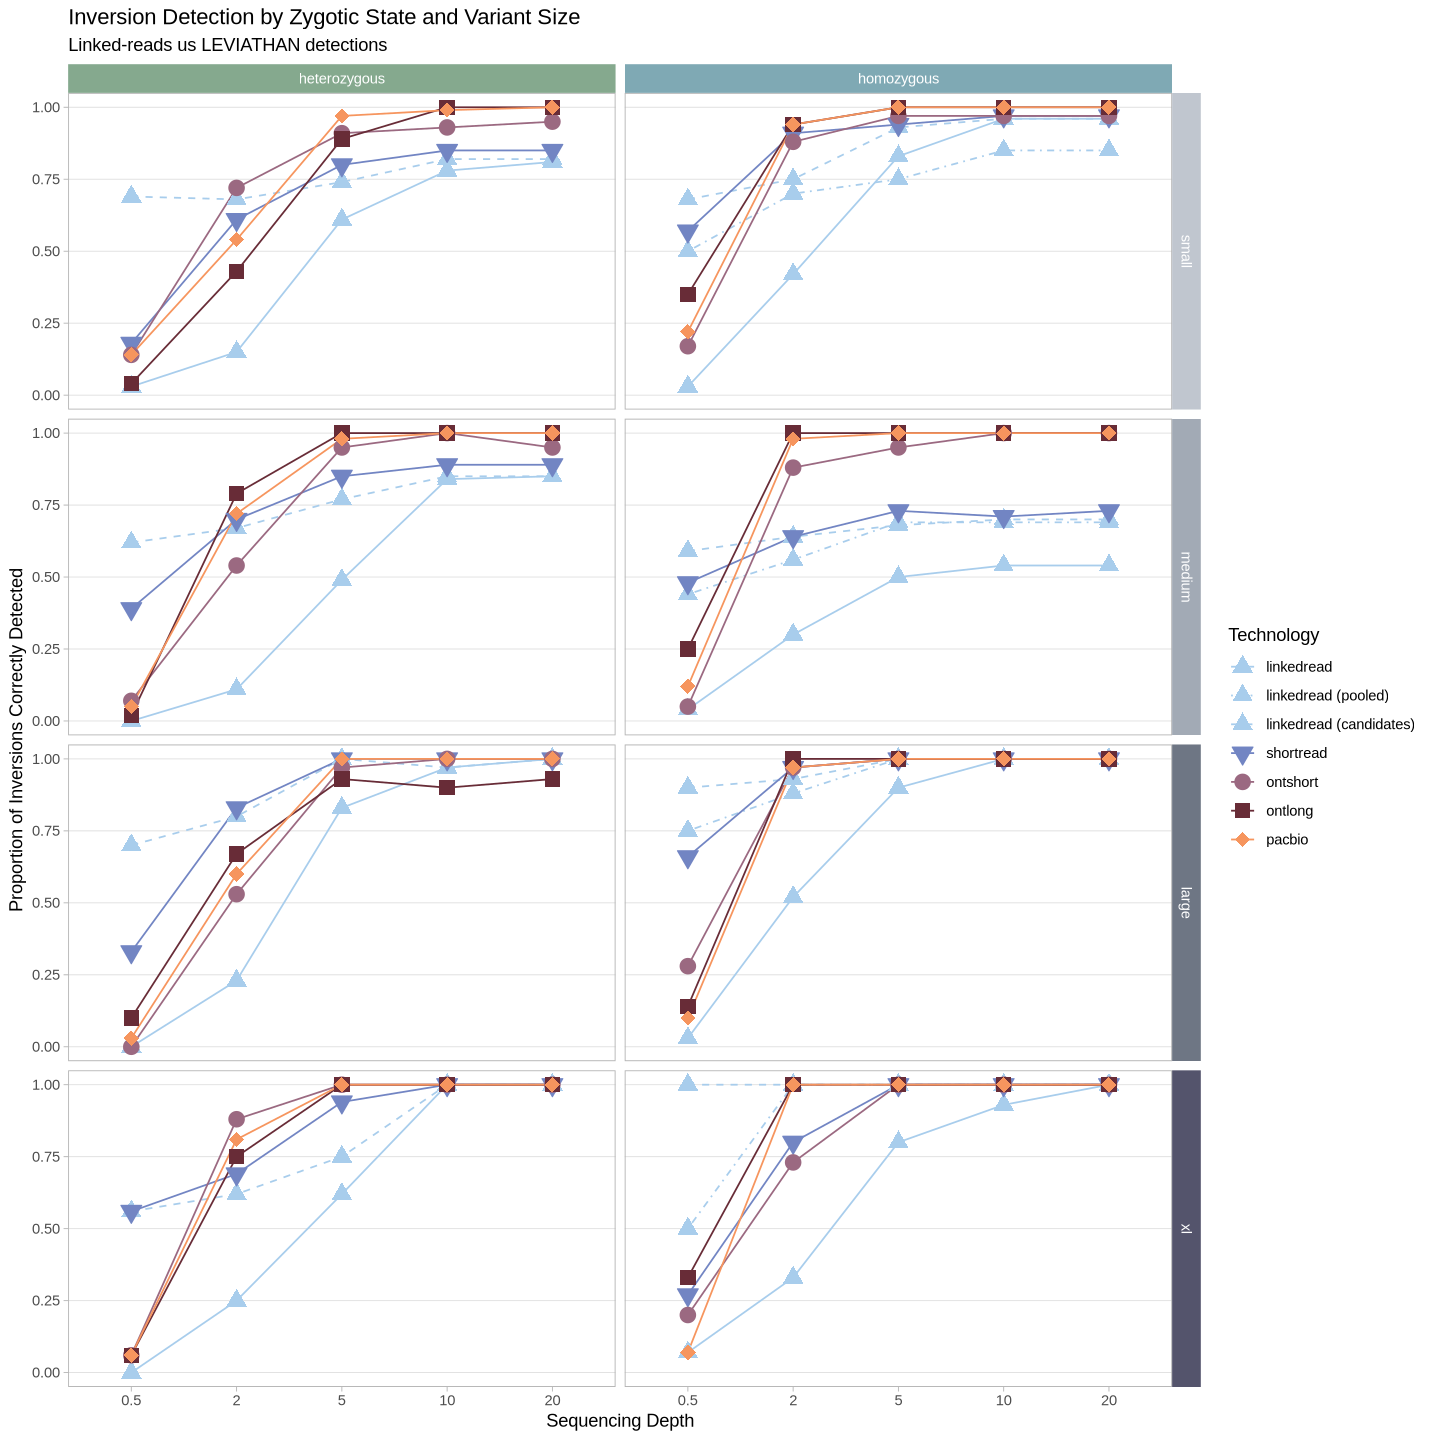

In [21]:
options(repr.plot.width = 12, repr.plot.height = 12)
.strip <- strip_themed(background_x = elem_list_rect(fill = zygosity_colors), background_y = elem_list_rect(fill = size_colors))

filter(samples, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = technology, fill = technology, group = technology, shape = technology)) +
    geom_line(aes(linetype = technology)) +
    geom_point(size = 4) +
    scale_linetype_manual(values = technology_lines) +
    scale_color_manual(values = tech_colors) +
    scale_fill_manual(values = tech_colors) +
    scale_shape_manual(values = technology_shapes) +
    theme_light() +
    labs(
        title = "Inversion Detection by Zygotic State and Variant Size",
        subtitle = "Linked-reads us LEVIATHAN detections",
        color = "Technology", shape = "Technology", fill = "Technology", linetype = "Technology") +
    ylab("Proportion of Inversions Correctly Detected") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(cols = vars(zygosity), rows = vars(size), strip = .strip)

Can also flip it horizontally

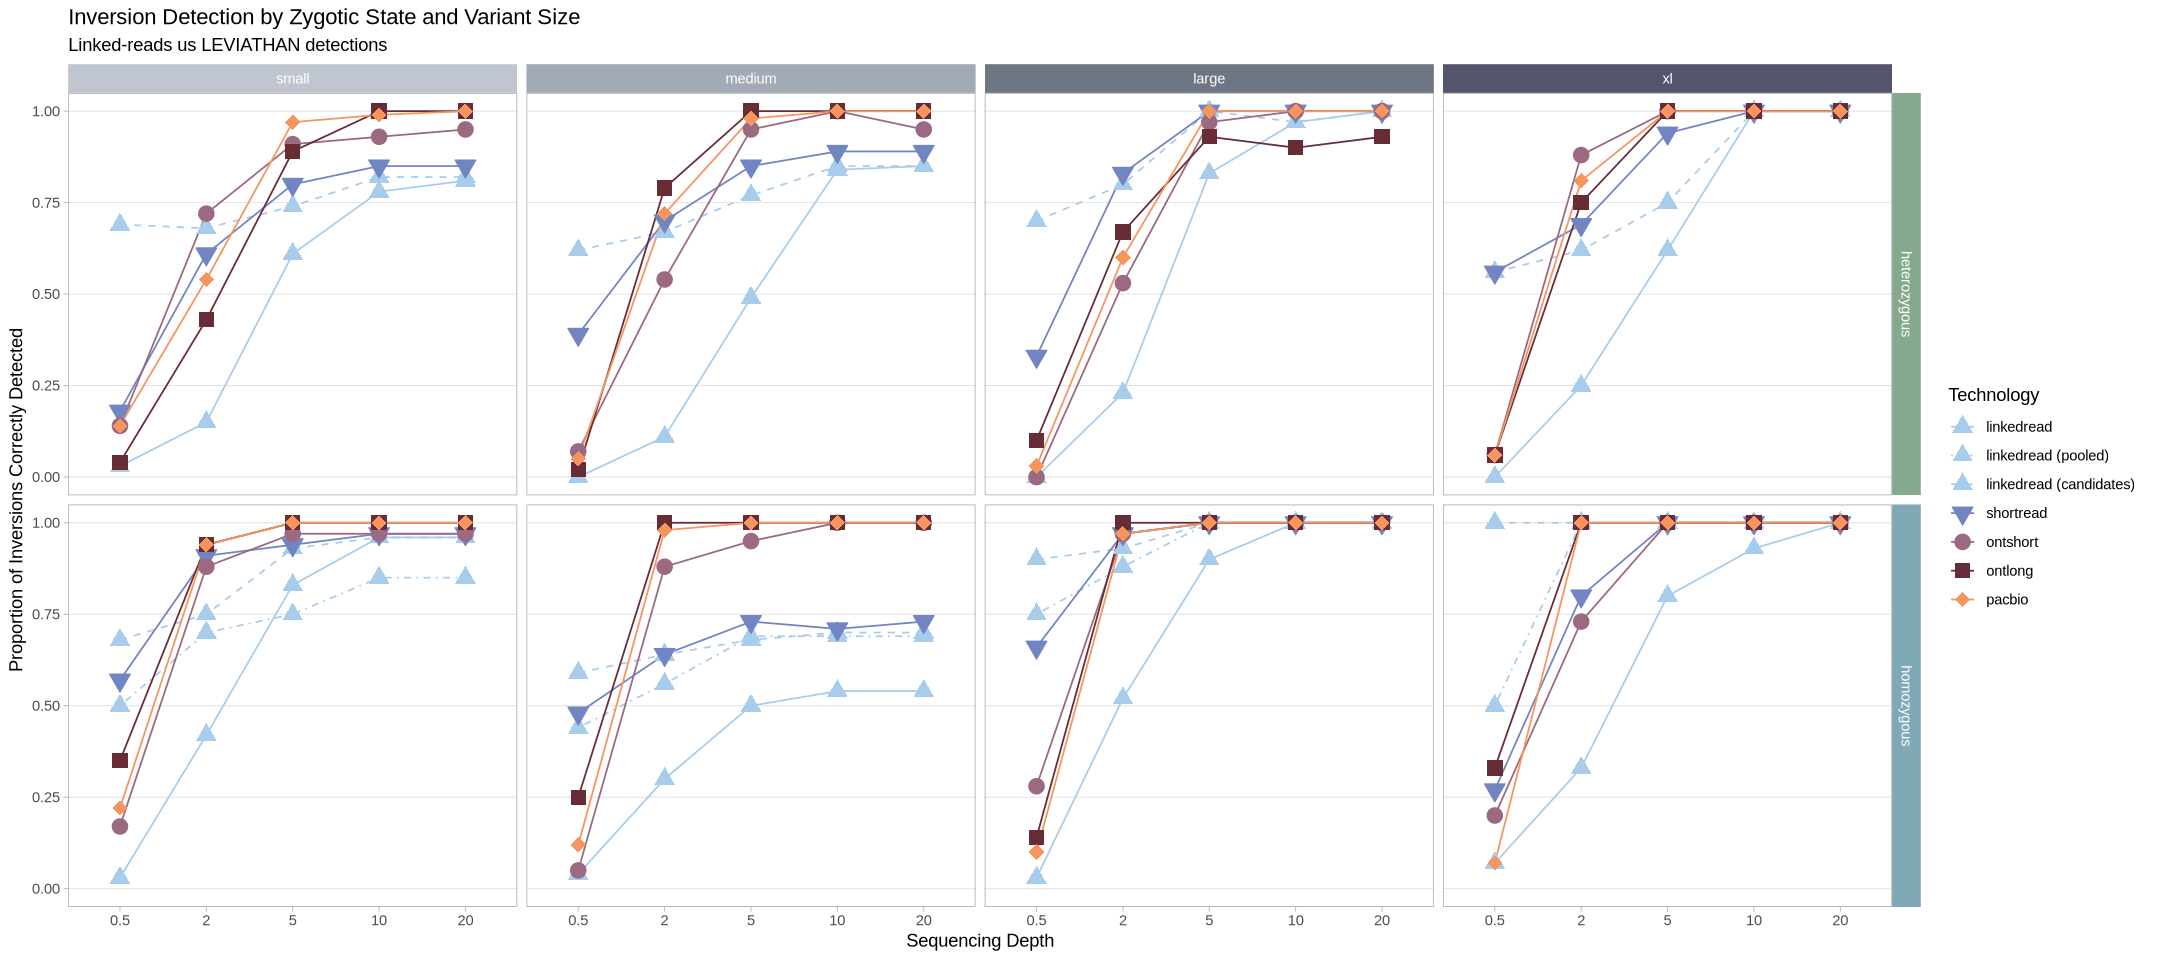

In [22]:
options(repr.plot.width = 18, repr.plot.height = 8)
.strip <- strip_themed(background_y = elem_list_rect(fill = zygosity_colors), background_x = elem_list_rect(fill = size_colors))

filter(samples, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = technology, fill = technology, group = technology, shape = technology)) +
    geom_line(aes(linetype = technology)) +
    geom_point(size = 4) +
    scale_linetype_manual(values = technology_lines) +
    scale_color_manual(values = tech_colors) +
    scale_fill_manual(values = tech_colors) +
    scale_shape_manual(values = technology_shapes) +
    theme_light() +
    labs(
        title = "Inversion Detection by Zygotic State and Variant Size",
        subtitle = "Linked-reads us LEVIATHAN detections",
        color = "Technology", shape = "Technology", fill = "Technology", linetype = "Technology") +
    ylab("Proportion of Inversions Correctly Detected") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(rows = vars(zygosity), cols = vars(size), strip = .strip)

#### Detection between inversion class within technologies
This is effectively the same thing, but it's a more 1:1 comparison across size classes within a given technology.

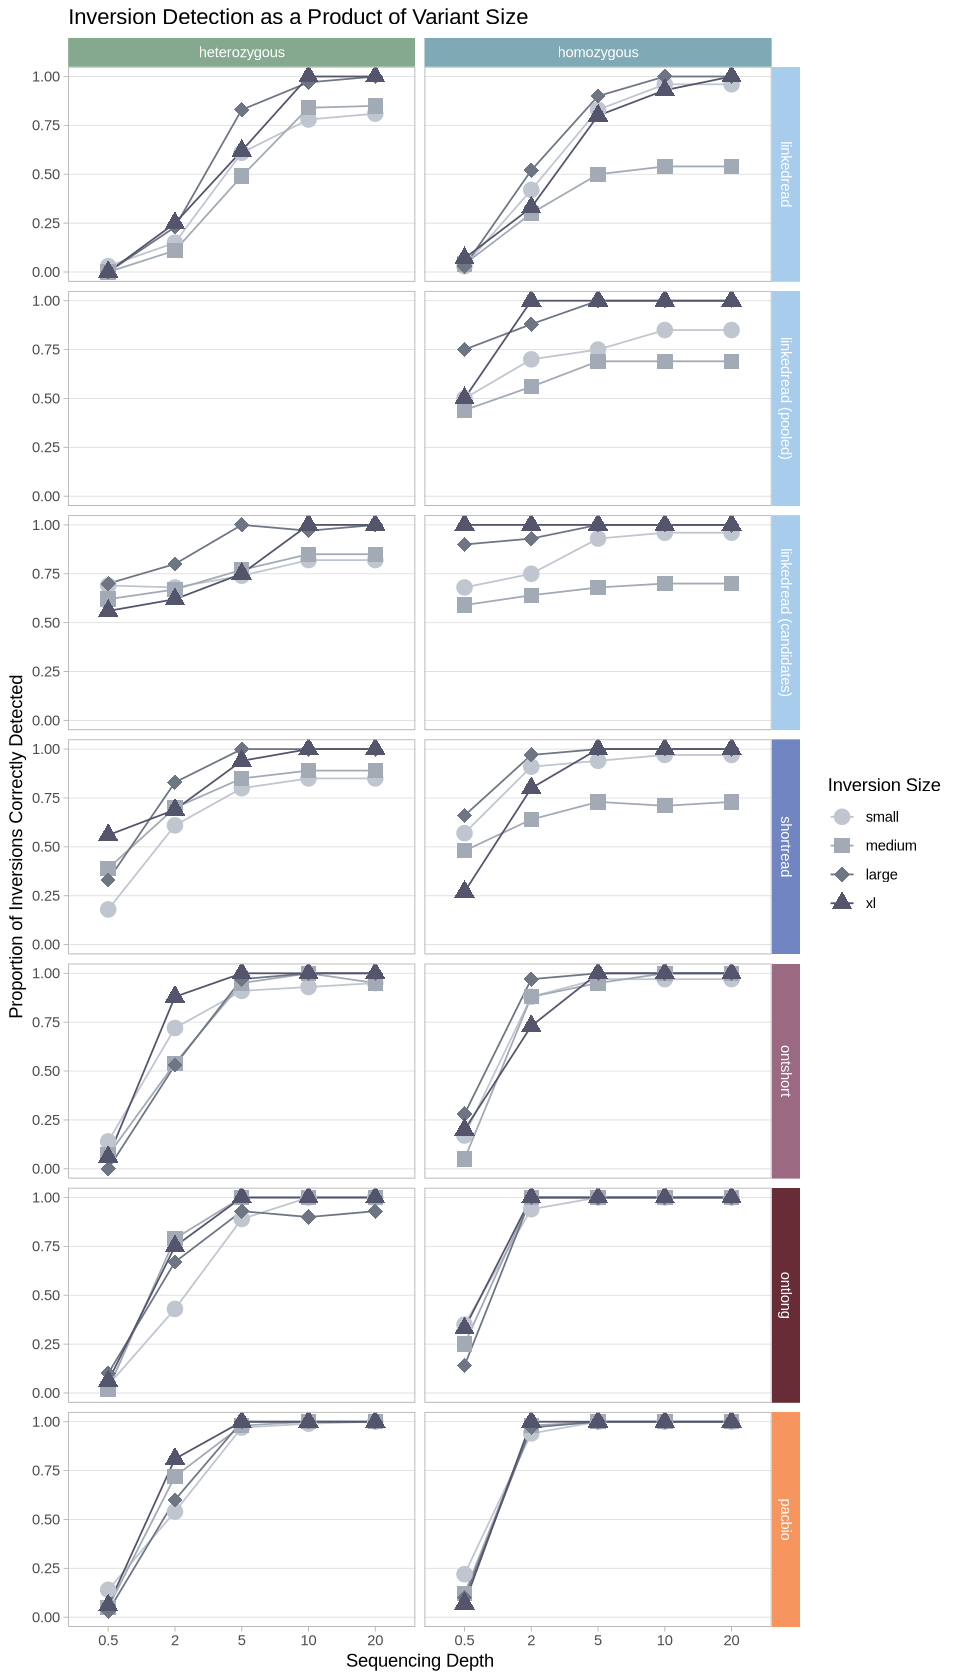

In [23]:
options(repr.plot.width = 8, repr.plot.height = 14)
.strip <- strip_themed(background_x = elem_list_rect(fill = zygosity_colors), background_y = elem_list_rect(fill = tech_colors[c(4,4,4,7,1,2,3)]))

filter(samples, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = size, group = size, shape = size)) +
    geom_line() +
    geom_point(size = 4) +
    scale_shape_manual(values = c(19,15,18,17)) +
    scale_color_manual(values = size_colors) +
    theme_light() +
    labs(title = "Inversion Detection as a Product of Variant Size", color = "Inversion Size", shape = "Inversion Size") +
    ylab("Proportion of Inversions Correctly Detected") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(cols = vars(zygosity), rows = vars(technology), strip = .strip)

Can also show it horizontally

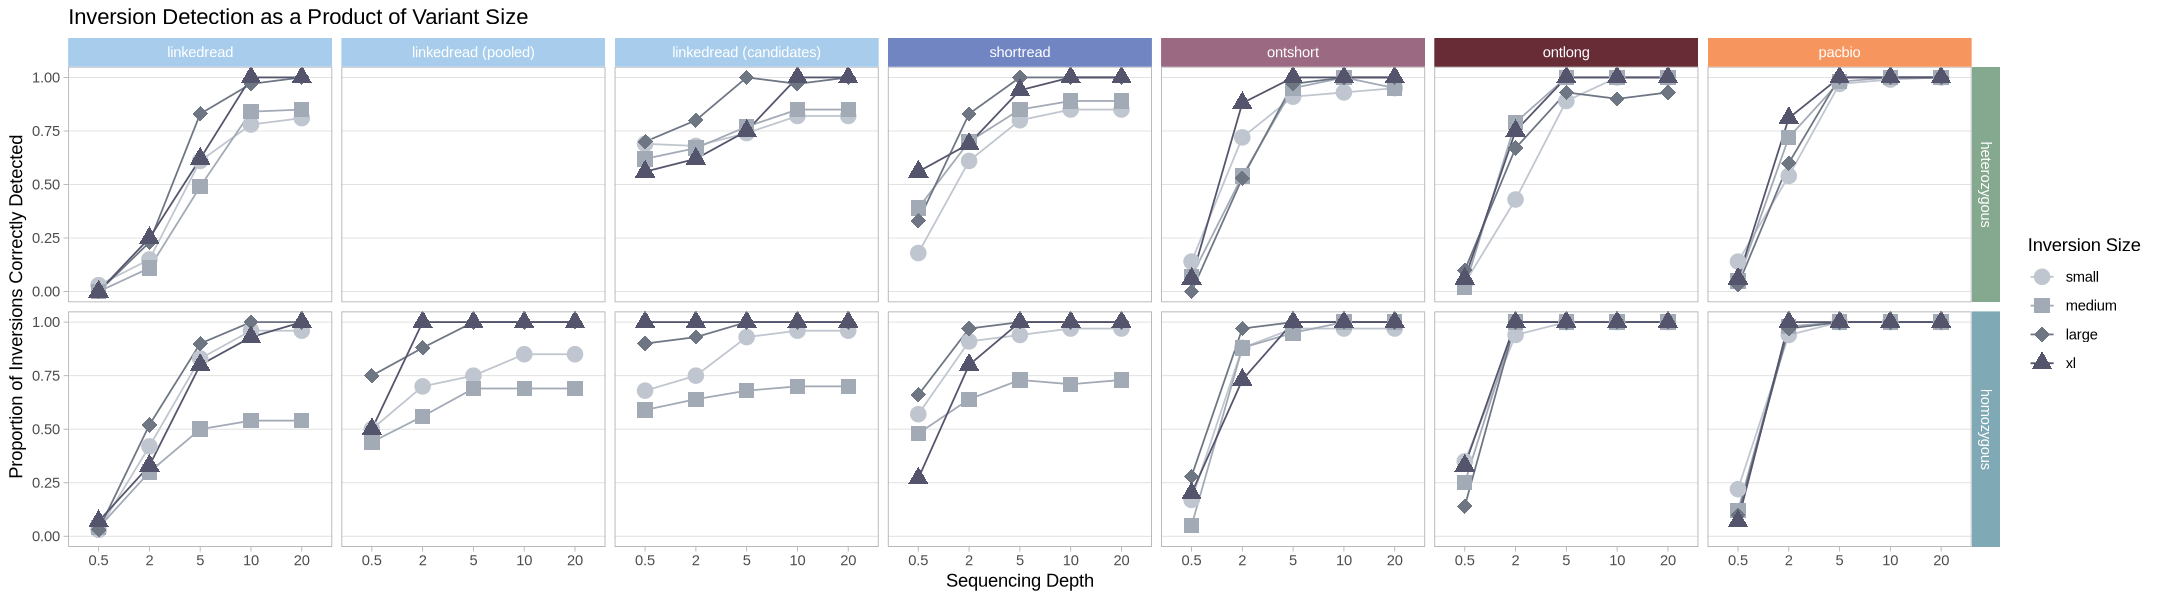

In [24]:
options(repr.plot.width = 18, repr.plot.height = 5)
.strip <- strip_themed(background_y = elem_list_rect(fill = zygosity_colors), background_x = elem_list_rect(fill = tech_colors[c(4,4,4,7,1,2,3)]))

filter(samples, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = size, group = size, shape = size)) +
    geom_line() +
    geom_point(size = 4) +
    scale_shape_manual(values = c(19,15,18,17)) +
    scale_color_manual(values = size_colors) +
    theme_light() +
    labs(title = "Inversion Detection as a Product of Variant Size", color = "Inversion Size", shape = "Inversion Size") +
    ylab("Proportion of Inversions Correctly Detected") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(rows = vars(zygosity), cols = vars(technology), strip = .strip)

#### Holistic comparison of technologies
What does it look like when we compare the performance of hom/het within and across technologies for each inversion class?

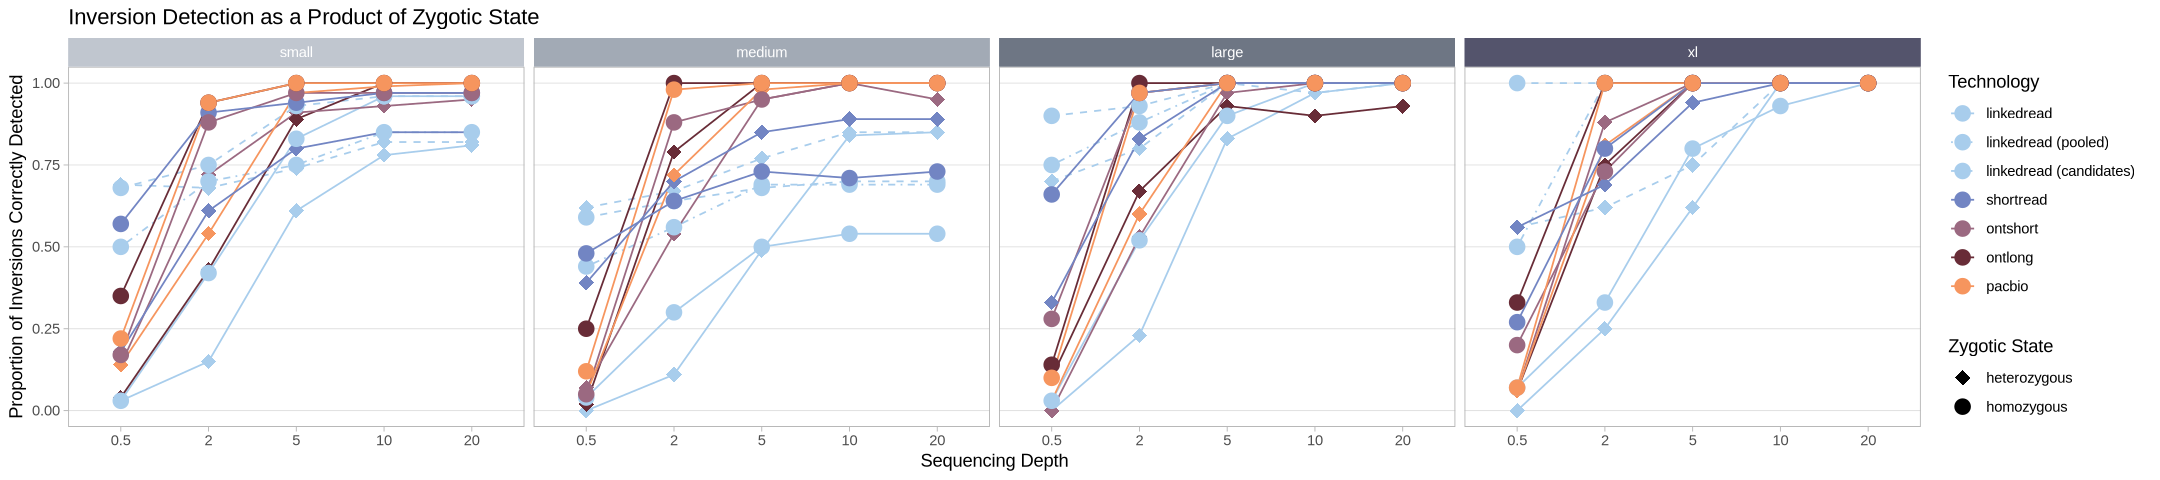

In [25]:
options(repr.plot.width = 18, repr.plot.height = 4)
.strip <- strip_themed(background_x = elem_list_rect(fill = size_colors))

filter(samples, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = technology, group = paste(technology, zygosity), shape = zygosity)) +
    geom_line(aes(linetype = technology)) +
    geom_point(aes(shape = zygosity), size = 4) +
    theme_light() +
    scale_color_manual(values = tech_colors) +
    scale_linetype_manual(values = technology_lines) +
    scale_shape_manual(values = c("homozygous"= 19,"heterozygous" = 18)) +
    labs(title = "Inversion Detection as a Product of Zygotic State", linetype = "Technology", color = "Technology", shape = "Zygotic State") +
    ylab("Proportion of Inversions Correctly Detected") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(cols = vars(size), strip = .strip)

Let's make it less busy by summing homozygous and heterozygous so it's a total assessment agnostic of zygotic state.

In [26]:
samples_consolidated <- group_by(samples, size, depth, technology, assessment) %>%
    summarise(count = sum(count)) %>%
    mutate(
        proportion = round(count/sum(count),2)
    ) %>% ungroup()
head(samples_consolidated)

`summarise()` has grouped output by 'size', 'depth', 'technology'. You can
override using the `.groups` argument.


size,depth,technology,assessment,count,proportion
<ord>,<fct>,<ord>,<chr>,<int>,<dbl>
small,0.5,linkedread,false negative,139,0.70
small,0.5,linkedread,true negative,57,0.28
small,0.5,linkedread,true positive,4,0.02
small,0.5,linkedread (pooled),false negative,10,0.50
small,0.5,linkedread (pooled),true negative,0,0.00
small,0.5,linkedread (pooled),true positive,10,0.50


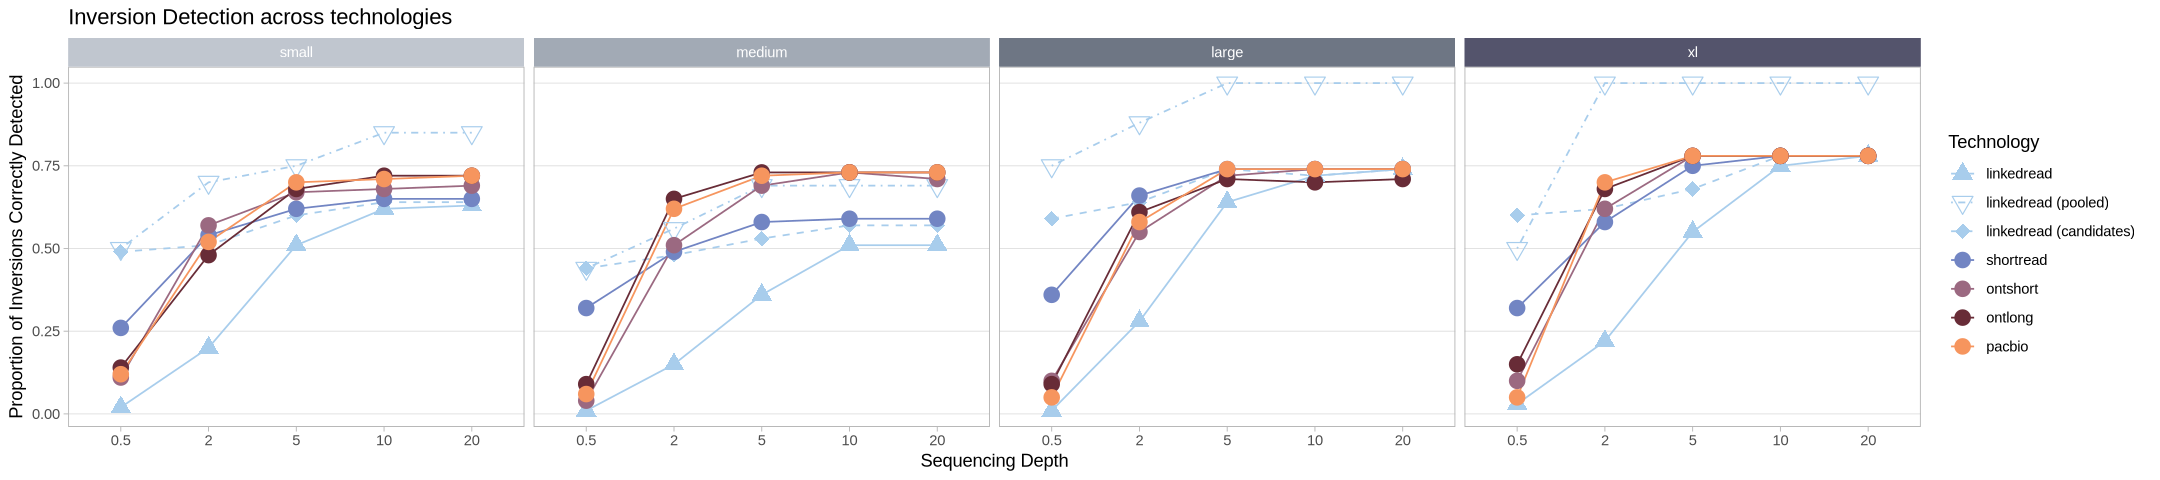

In [27]:
filter(samples_consolidated, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = technology, group = technology)) +
    geom_line(aes(linetype = technology)) +
    geom_point(size = 4, aes(shape = technology)) +
    theme_light() +
    scale_color_manual(values = tech_colors) +
    scale_linetype_manual(values = technology_lines) +
    scale_shape_manual(values = technology_shapes2) +
    labs(title = "Inversion Detection across technologies", linetype = "Technology", color = "Technology", shape = "Technology") +
    ylab("Proportion of Inversions Correctly Detected") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(cols = vars(size), strip = .strip)

## F-Score
Let's look at the comparison of Precision vs Recall by using the F1 score. To start, we'll need to read in all the false positives across the different methods.

In [28]:
# this function automates reading in everything all at once returns an empty table if there are no false positives
read.fp <- function(dir){
    val <- Reduce(
       rbind,
        Map(
            function(x){ read.table(x, header = T)},
            list.files(dir, pattern = "false_positives*", full.names = T)
        )
    )
    if (is.null(val)){
        return(
            data.frame(
                contig = character(),
                position_start = integer(),
                position_end = integer(),
                sample = integer(),
                depth = numeric(),
                size = character(),
                method = character()
            )
        )
    } else {
        return(val)
    }
}

In [29]:
false_positives <- Reduce(
    rbind,
    Map(
        read.fp,
        c("assess_sv_delly", "assess_sv_leviathan/visor", "longread_workflow")
    )
)

false_positives$assessment <- "false positive"
false_positives <- rename(false_positives, "technology" = method)
false_positives$technology <- gsub("delly", "shortread", false_positives$technology)
head(false_positives)

,contig,position_start,position_end,sample,depth,size,technology,assessment
,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>
1,2L,6436108,6636405,4,0.5,medium,shortread,false positive
2,3L,1700609,1761574,9,0.5,medium,shortread,false positive
3,3L,1700628,1761915,1,0.5,medium,shortread,false positive
4,3L,1700628,1761915,6,0.5,medium,shortread,false positive
5,2L,6436142,6636405,1,2.0,medium,shortread,false positive
6,2L,6436142,6636405,2,2.0,medium,shortread,false positive


In [36]:
metrics <- group_by(false_positives, size, depth, assessment, technology) %>%
    summarize(count = n()) %>% ungroup() %>%
    rbind(select(samples_consolidated, -proportion)) %>%
    arrange(size, depth, technology, assessment) %>%
    filter(technology != "linkedread (candidates)") %>%
    complete(size, depth, technology, assessment = .assess, fill = list(count = 0)) %>%
    pivot_wider(names_from = assessment, values_from = count)
names(metrics) <- c("size", "depth", "technology", "FN", "FP", "TN", "TP")
head(metrics)

`summarise()` has grouped output by 'size', 'depth', 'assessment'. You can
override using the `.groups` argument.


size,depth,technology,FN,FP,TN,TP
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
large,0.5,linkedread,58,0,21,1
large,0.5,linkedread (pooled),2,0,0,6
large,0.5,ontlong,52,0,21,7
large,0.5,ontshort,51,0,21,8
large,0.5,pacbio,55,0,21,4
large,0.5,shortread,30,0,21,29


In [39]:
metrics$precision <- metrics$TP / (metrics$TP + metrics$FP)
metrics$recall <- metrics$TP / (metrics$TP + metrics$FN)
metrics$F1 <- 2 * ((metrics$precision * metrics$recall) / (metrics$precision + metrics$recall))
metrics$depth <- metrics$depth
metrics$size <- factor(metrics$size, ordered = T, levels = c("small", "medium", "large", "xl"))
metrics$depth <- factor(metrics$depth, ordered = T, levels = c("0.5", "2", "5", "10", "20"))
head(metrics)

size,depth,technology,FN,FP,TN,TP,precision,recall,F1
<ord>,<ord>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
large,0.5,linkedread,58,0,21,1,1,0.01694915,0.03333333
large,0.5,linkedread (pooled),2,0,0,6,1,0.75000000,0.85714286
large,0.5,ontlong,52,0,21,7,1,0.11864407,0.21212121
large,0.5,ontshort,51,0,21,8,1,0.13559322,0.23880597
large,0.5,pacbio,55,0,21,4,1,0.06779661,0.12698413
large,0.5,shortread,30,0,21,29,1,0.49152542,0.65909091


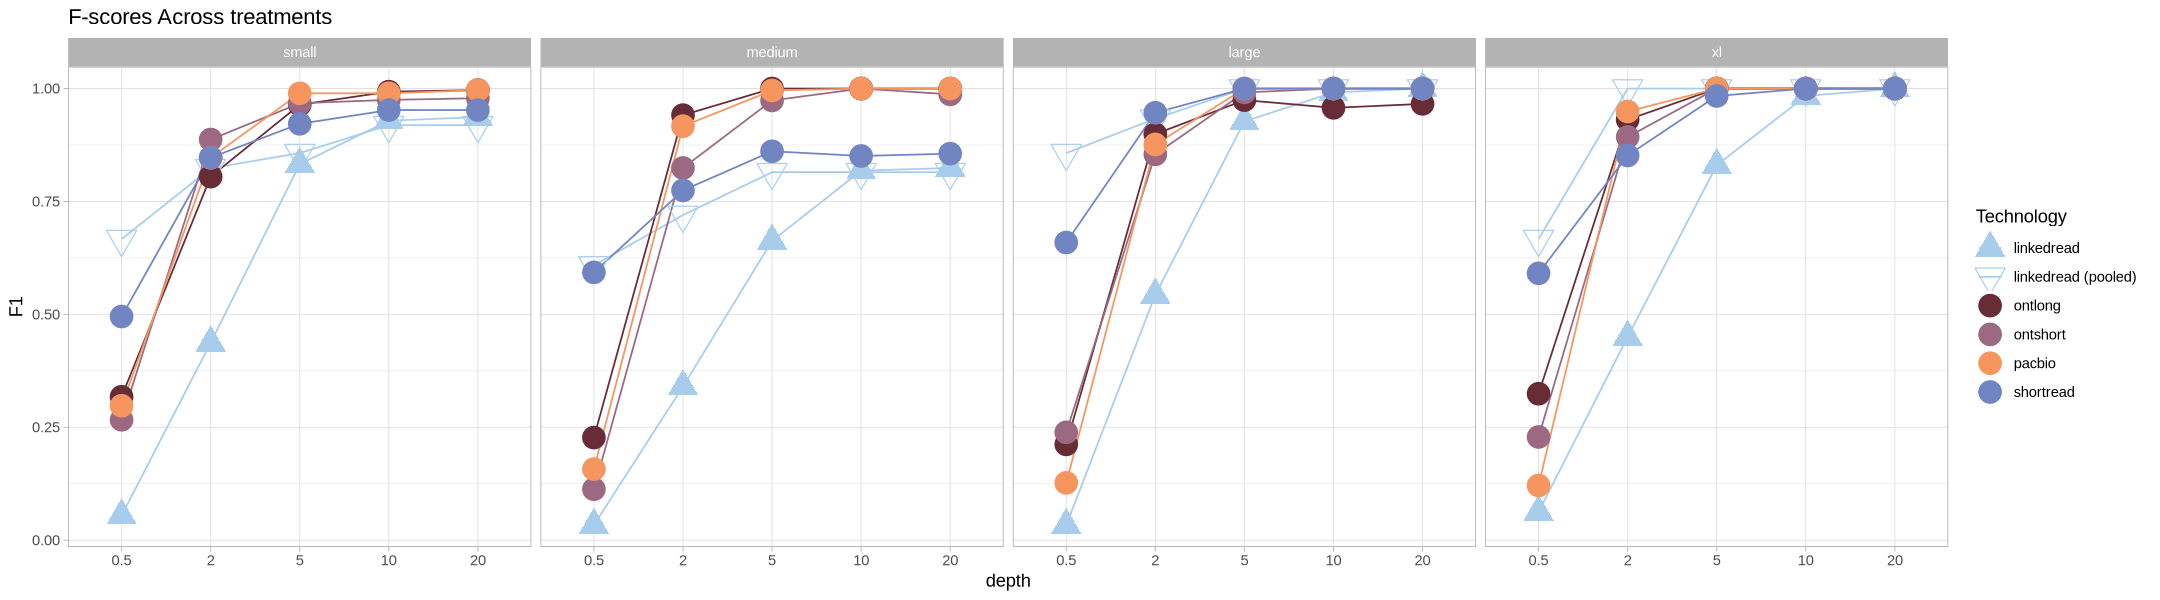

In [40]:
options(warn = -1, repr.plot.width = 18, repr.plot.height = 5)
ggplot(metrics, aes(x = depth, y = F1, color = technology, shape = technology, group = technology)) +
    geom_line() +
    geom_point(size = 6) +
    theme_light() +
    scale_shape_manual(name = "Technology", values = technology_shapes2) +
    scale_color_manual(name = "Technology", values = tech_colors) +
    labs(title = "F-scores Across treatments") +
    facet_grid(cols = vars(size))